In [1]:
import sys

import pandas as pd

sys.path.append("..")


from utils.gloer_tools import (
    exog_gloer,
    load_gloer,
    weather_gloer,
    make_model_hp_list,
    build_gloer_exog,
)
from statsmodels.tsa.deterministic import Fourier
from utils.baseline_tools import build_sarimax_ds, param_holder
from utils.gloer_tools import score_gloer, results_to_pd, transform_res_to_param_holder, prep_for_analysis
from functools import reduce
import matplotlib.pyplot as plt
import pickle
import numpy as np

from utils.filters import custom_fourier_terms, decompose_data
import statsmodels.api as sm


ImportError: cannot import name 'dl_to_raw_ts_new' from 'utils.baseline_tools' (/home/stein/project_repos/dam/publish/glörtal_analysis/../utils/baseline_tools.py)

In [ ]:
%load_ext autoreload
%autoreload 2

# Analysis: 

- Check if there is a model that is reasonable in both periods.
- If yes: What variables are included and how?
- Check if the external variables are all used.

In [61]:
#r = pickle.load(open("../saves_and_results/gloer_grid/results_stack.p", "rb"))
single = pickle.load(open("../saves_and_results/gloer_grid/ASCE_088_03_results_stack.p", "rb"))

In [62]:
data, meta = load_gloer(remove_last_year=False, interpolate_endog=False)
stau, sicker = exog_gloer()
weather = weather_gloer()
d = (data["ASCE_088_02"] - data["ASCE_088_02"].min()) / (data["ASCE_088_02"].max() - data["ASCE_088_02"].min())
deseasoned, seasonality, trend = decompose_data(d)


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [11]:
exog = build_gloer_exog(
    data["ASCE_088_02"],
    stau,
    weather,
    weather_variables=["temperature"],
    fourier_order=0,
    external_timesteps=[[1],[1]],
    mean_period=[0,0],
)
exog = ((exog - exog.min()) / (exog.max() - exog.min()))


<AxesSubplot:xlabel='datetime'>

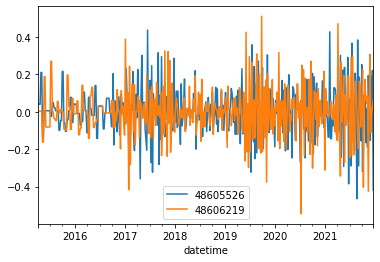

In [20]:
(deseasoned.interpolate() -  deseasoned.interpolate().shift(1)).plot()

<AxesSubplot:xlabel='datetime'>

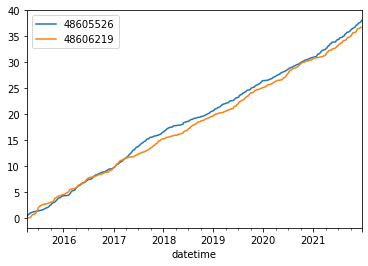

In [26]:
deseasoned.interpolate().abs().cumsum().plot()

In [16]:
(deseasoned - deseasoned.shift(1)).interpolate()

,48605526,48606219
datetime,,
2015-04-09,NaN,NaN
2015-04-15,NaN,NaN
2015-04-21,NaN,NaN
2015-04-27,NaN,NaN
2015-05-03,NaN,NaN
...,...,...
2021-11-27,-0.153886,0.306299
2021-12-03,0.189096,-0.112535
2021-12-09,-0.014550,-0.012956


In [39]:
d[:,]

Index([48605526, 48606219], dtype='object')

<AxesSubplot:xlabel='datetime'>

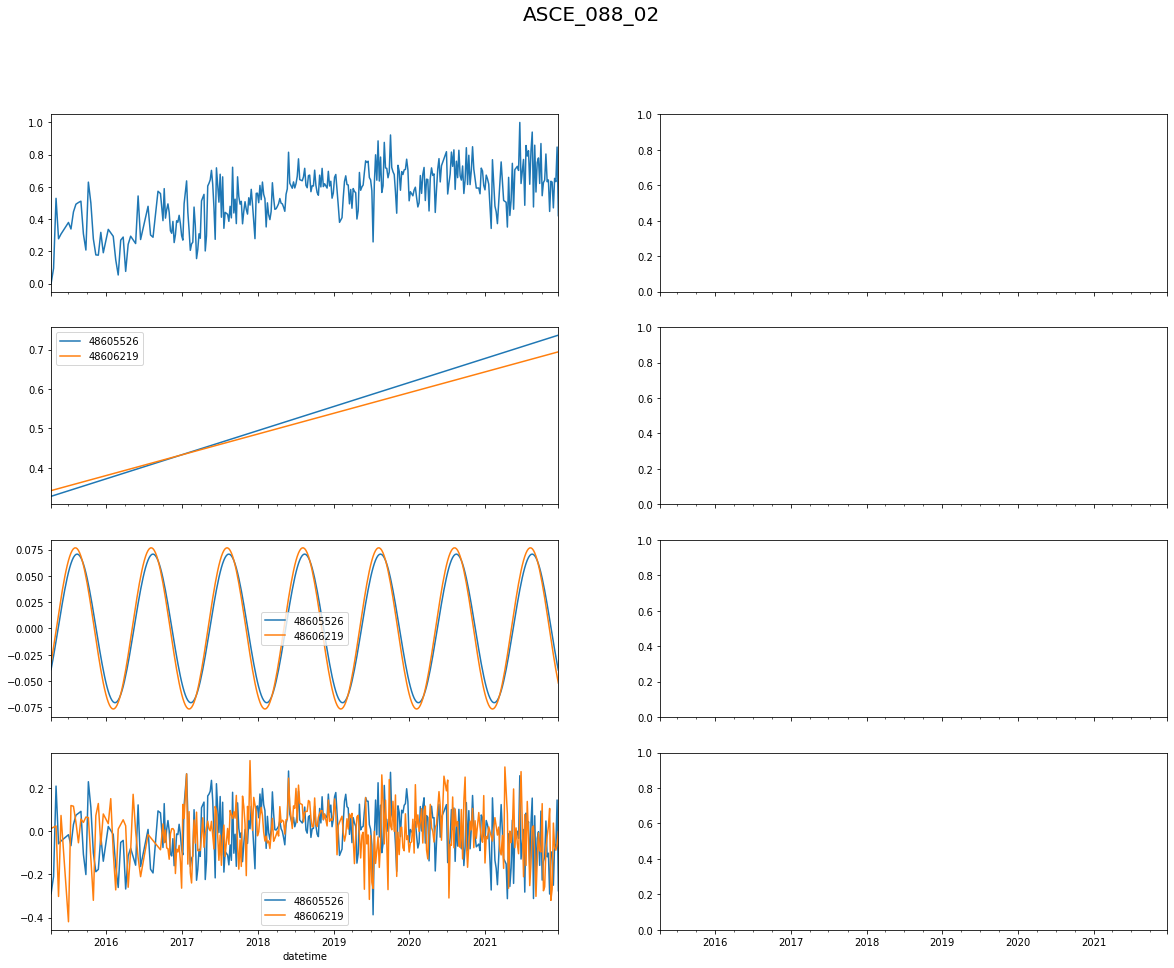

In [42]:
i = d.columns
fig, axs = plt.subplots(4, 2, figsize=(20, 15),sharex=True)
fig.suptitle('ASCE_088_02', fontsize=20)
for n, m in enumerate(i):
d.loc[:,i[0]].interpolate().plot(ax=axs[0,0])
trend.plot(ax=axs[1,0],)
seasonality.plot(ax=axs[2,0])
deseasoned.interpolate().plot(ax=axs[3,0])

<AxesSubplot:xlabel='date'>

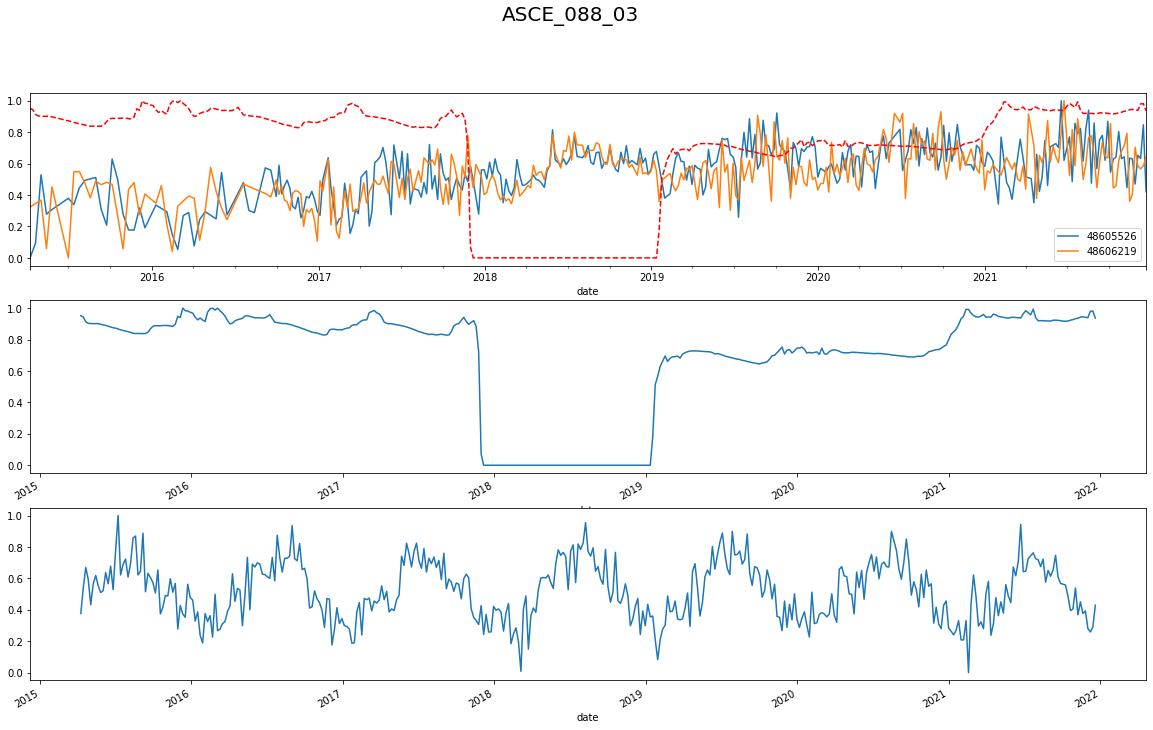

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(20, 12))
fig.suptitle('ASCE_088_03', fontsize=20)
d.plot(ax=axs[0])
exog["W_1"].plot(ax=axs[1])
exog["temperature_1"].plot(ax=axs[2])
#exog["sin_order_1"].plot(ax=axs[1,1])
exog["W_1"].plot(ax=axs[0], color="r", linestyle="dashed")

# Selection criteria: 

- Extrapolate well to P1
- Extrapolate well to P2



In [4]:
data, meta = load_gloer(remove_last_year=False, interpolate_endog=True)
stau, sicker = exog_gloer()
weather = weather_gloer()

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [11]:
single = pickle.load(open("../saves_and_results/gloer_grid/ASCE_088_03_results_stack.p", "rb"))

In [12]:
scores =results_to_pd(single[1:])
scores

[0, 0, 1, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[0, 0, 2, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[0, 1, 0, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[0, 1, 1, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[0, 1, 2, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[1, 0, 0, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[1, 0, 1, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[1, 0, 2, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[1, 1, 0, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[1, 1, 1, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[1, 1, 2, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[2, 0, 0, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[2, 0, 1, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[2, 0, 2, 0, [array([], dtype=int64), array([], dtype=int64)], [0, 0]]
[2, 1,

,index,0,1,2,0,1,2,0,1,2,3,4,5,6,7
0,53387174,0.029437,-57.964018,0.403658,0.007764,-92.812538,0.101190,0,0,0,0,[],[],0,3
1,53387842,0.021025,-121.866843,0.311074,0.002123,-129.371052,0.058169,0,0,0,0,[],[],0,3
2,53387174,0.039226,-71.136217,0.485442,0.007376,-92.687356,0.097900,0,0,0,0,[],[],3,0
3,53387842,0.019523,-124.486704,0.303316,0.001201,-111.822109,0.052848,0,0,0,0,[],[],3,0
4,53387174,0.039389,-69.152916,0.486367,0.007764,-90.812538,0.101190,0,0,0,0,[],[],3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,53387842,0.020624,-148.504146,0.309285,0.004612,-111.691447,0.097545,2,1,2,0,"[0, 1, 2]","[0, 1, 2]",0,3
2264,53387174,0.054358,-83.087636,0.592642,0.020465,-74.710983,0.164581,2,1,2,0,"[0, 1, 2]","[0, 1, 2]",3,0
2265,53387842,0.020970,-145.703852,0.315961,0.004516,-111.729569,0.097192,2,1,2,0,"[0, 1, 2]","[0, 1, 2]",3,0
2266,53387174,0.058070,-81.581239,0.613067,0.022337,-73.915590,0.169066,2,1,2,0,"[0, 1, 2]","[0, 1, 2]",3,3


In [13]:
scores.columns = [
    "index",
    "MSEP1",
    "AICP1",
    "MAPE1",
    "MSEP2",
    "AICP2",
    "MAPE2",
    "P",
    "D",
    "Q",
    "F",
    "Exog Water",
    "Exog Temp",
    "Mean W",
    "Mean T",
]

In [79]:
scores["Exog Temp"]

0              []
1              []
2              []
3              []
4              []
          ...    
2263    [0, 1, 2]
2264    [0, 1, 2]
2265    [0, 1, 2]
2266    [0, 1, 2]
2267    [0, 1, 2]
Name: Exog Temp, Length: 2268, dtype: object

In [80]:
scores.sort_values("MSEP1")[:10]

,index,MSEP1,AICP1,MAPE1,MSEP2,AICP2,MAPE2,P,D,Q,F,Exog Water,Exog Temp,Mean W,Mean T
2061,53387842,0.018353,-150.006128,0.297183,0.001597,-112.622953,0.053895,2,1,1,0,[0],[0],3,3
1365,53387842,0.018464,-149.661416,0.290417,0.002213,-118.016391,0.058793,1,1,1,0,"[0, 1, 2]",[0],0,3
1399,53387842,0.018502,-151.015257,0.297603,0.001475,-114.337933,0.054152,1,1,2,0,[],[0],3,3
1651,53387842,0.018522,-168.650480,0.295552,0.001579,-123.418591,0.053442,2,0,1,0,[],[0],3,3
1427,53387842,0.018569,-151.469890,0.296177,0.001475,-114.337933,0.054152,1,1,2,0,[0],[0],0,3
1443,53387842,0.018711,-148.487881,0.299483,0.002650,-112.671390,0.068705,1,1,2,0,[0],"[0, 1, 2]",0,3
1273,53387842,0.018729,-152.704175,0.300284,0.001465,-116.327182,0.054090,1,1,1,0,[],[0],3,3
2089,53387842,0.018805,-153.858710,0.296920,0.001647,-114.114751,0.050916,2,1,1,0,"[0, 1]",[0],0,3
1431,53387842,0.018816,-149.812860,0.297995,0.001475,-112.337933,0.054152,1,1,2,0,[0],[0],3,3
1301,53387842,0.018831,-152.650943,0.300281,0.001465,-116.327182,0.054090,1,1,1,0,[0],[0],0,3


In [81]:
scores.sort_values("MSEP2")[:10]

,index,MSEP1,AICP1,MAPE1,MSEP2,AICP2,MAPE2,P,D,Q,F,Exog Water,Exog Temp,Mean W,Mean T
1461,53387842,0.021148,-149.398123,0.324193,0.001004,-112.332913,0.048267,1,1,2,0,"[0, 1]",[0],3,0
1457,53387842,0.021449,-152.400531,0.322499,0.001004,-114.332913,0.048267,1,1,2,0,"[0, 1]",[0],0,0
1335,53387842,0.020703,-148.782927,0.324522,0.001028,-113.928244,0.047399,1,1,1,0,"[0, 1]",[0],3,0
1331,53387842,0.020745,-152.410994,0.318531,0.001028,-115.928288,0.047398,1,1,1,0,"[0, 1]",[0],0,0
579,53387842,0.031479,-126.322208,0.282175,0.001030,-116.044946,0.048299,0,1,1,0,"[0, 1]",[0],3,0
575,53387842,0.031324,-128.348842,0.284214,0.001030,-118.044946,0.048299,0,1,1,0,"[0, 1]",[0],0,0
2217,53387842,0.020305,-151.196519,0.316358,0.001037,-112.091709,0.044726,2,1,2,0,"[0, 1]",[0],3,0
2213,53387842,0.020387,-153.729327,0.313480,0.001038,-114.094454,0.044707,2,1,2,0,"[0, 1]",[0],0,0
705,53387842,0.021069,-144.247879,0.324298,0.001046,-114.026407,0.051265,0,1,2,0,"[0, 1]",[0],3,0
701,53387842,0.021138,-146.494527,0.324716,0.001046,-116.025727,0.051266,0,1,2,0,"[0, 1]",[0],0,0


# Refit model and observe predictions:

In [5]:
index = 1461
endog = data["ASCE_088_03"]
deseasoned, seasonality, trend = decompose_data(endog)

exog = build_gloer_exog(
        deseasoned,
        stau,
        weather,
        weather_variables=["temperature"],
        fourier_order=0,
        external_timesteps=[[0],[0]],
        mean_period=[0,0]
    )
phases = prep_for_analysis(deseasoned, exog, simple_split=True)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [14]:
scores.iloc[index]["index"]

53387842

In [9]:
phases["p2"][0][0]

,53387174,53387842
datetime,,
2017-11-30,0.709445,0.632108
2017-12-06,0.510413,0.461145
2017-12-12,0.487417,0.777519
2017-12-18,0.463875,0.661505
2017-12-24,0.597424,0.544889
2017-12-30,0.639678,0.418325
2018-01-05,0.747574,0.569269
2018-01-11,0.747422,0.543779
2018-01-17,0.697175,0.652727


In [96]:
mod = sm.tsa.statespace.SARIMAX(
    phases["p2"][0][0][scores.iloc[index]["index"]].values,
    phases["p2"][0][1],
    order=scores.loc[index,["P", "D", "Q"]].values,
    trend="c",
    use_exact_diffuse=True,
)
res = mod.fit(disp=False)
       

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)


In [97]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   58
Model:               SARIMAX(1, 1, 2)   Log Likelihood                  65.643
Date:                Tue, 24 Oct 2023   AIC                           -115.287
Time:                        01:03:20   BIC                            -98.803
Sample:                    11-30-2017   HQIC                          -108.866
                         - 11-07-2018                                         
Covariance Type:                  opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        -0.0006      0.009     -0.065      0.948      -0.018       0.017
temperature_0     0.0913      0.087      1.050      0.294      -0.079       0.262
W_0                    0        nan        nan        nan         nan         nan
ar.L1            -0.2684     18.331     -0.015      0.988     -36.196      35.660
ma.L1            -0.4756     18.381     -0.026      0.979     -36.501      35.550
ma.L2            -0.2069     13.760     -0.015      0.988     -27.176      26.762
sigma2            0.0056      0.001      4.679      0.000       0.003       0.008
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.17
Prob(Q):                              0.91   Prob(JB):                         0.56
Heteroskedasticity (H):               0.41   Skew:                             0.19
Prob(H) (two-sided):                  0.06   Kurtosis:                         3.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.72e+21. Standard errors may be unstable.
"""

<AxesSubplot:xlabel='datetime'>

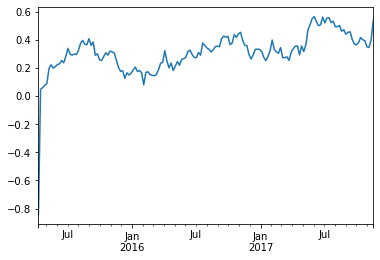

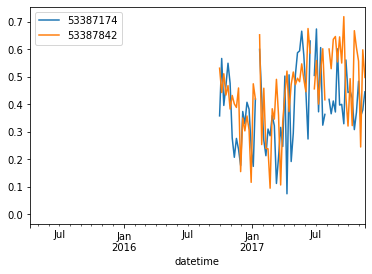

In [60]:
res.predict().plot()
phases["p2"][0][0].plot()

In [11]:
score_gloer(transform_res_to_param_holder(scores,420), data["ASCE_088_03"], weather, stau, simple_split=True)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarn

[[0,
  0,
  1,
  2,
  array([array([0, 1, 2]), array([0, 1])], dtype=object),
  array([3, 0], dtype=object)],
 {53387174: (0.014239907631642928, -194.31062920300747),
  53387842: (0.02319381913928362, -204.34689654102266)},
 {53387174: (0.6359043707797613, -227.41876297202037),
  53387842: (0.2754379401729062, -224.9578969204117)}]

In [10]:
transform_res_to_param_holder(scores,420)

In [179]:
p1,p2,p3

([2, 0, 1, 0], [0, 0], [[0, 1], [0, 1]])

In [167]:
p3

[[0], [0]]

In [116]:
s[13:-9].replace("array(", "").replace(")", "")[1:-1].split("], [")

['[0', '0]']

In [180]:
def transform_res_str_to_param_holder(s):
    p1 = [int(x) for x in s[1:11].split(",")]
    p2 = [int(x) for x in s[-6:-2].split(",")]
    p3 = s[14:-10].split(", array")
    p3 = [[int(x) for x in p3[0][7:-2].split(",")],[int(x) for x in p3[1][2:-2].split(",")]]
    return param_holder(
        p=p1[0],
        d=p1[1],
        q=p1[2],
        f=p1[3],
        ex=p3,
        mean=p2,
    )

In [217]:
stack[-1]

[2, 1, 2, 2, [[0, 1, 2], [0, 1, 2]], [3, 3]]

In [225]:
stack

[[0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 3],
 [0, 0, 0, 0, 0, 0, 0, 3],
 [0, 0, 0, 0, 0, 0, 3, 0],
 [0, 0, 0, 0, 0, 0, 3, 0],
 [0, 0, 0, 0, 0, 0, 3, 3],
 [0, 0, 0, 0, 0, 0, 3, 3],
 [0, 0, 0, 0, 0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 3],
 [0, 0, 0, 0, 0, 0, 1, 0, 3],
 [0, 0, 0, 0, 0, 0, 1, 3, 0],
 [0, 0, 0, 0, 0, 0, 1, 3, 0],
 [0, 0, 0, 0, 0, 0, 1, 3, 3],
 [0, 0, 0, 0, 0, 0, 1, 3, 3],
 [0, 0, 0, 0, 0, 0, 1, 2, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 2, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 2, 0, 3],
 [0, 0, 0, 0, 0, 0, 1, 2, 0, 3],
 [0, 0, 0, 0, 0, 0, 1, 2, 3, 0],
 [0, 0, 0, 0, 0, 0, 1, 2, 3, 0],
 [0, 0, 0, 0, 0, 0, 1, 2, 3, 3],
 [0, 0, 0, 0, 0, 0, 1, 2, 3, 3],
 [0, 0, 0, 0, 0, 1, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 3],
 [0, 0, 0, 0, 0, 1, 0, 0, 3],
 [0, 0, 0, 0, 0, 1, 0, 3, 0],
 [0, 0, 0, 0, 0, 1, 0, 3, 0],
 [0, 0, 0, 0, 0, 1, 0, 3, 3],
 [0, 0, 0, 0, 0, 1, 0, 3, 3],
 [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
 [0, 0,

In [207]:
    a[:4] + [a[-2][0]] + [a[-2][1]] + [a[-1][0]]  + [a[-1][1]]


[0, 0, 0, 0, [0], [0], 0, 0]

In [223]:
stack = []
for x in transform["params"].values:
    a =transform_res_str_to_param_holder(x).export()[:-1]
    stack.append(a[:4] + a[-2][0] + a[-2][1] + [a[-1][0]]  + [a[-1][1]]
)



params = pd.DataFrame(
    [
       stack
    ],
    index=["P", "D", "Q", "F", "EX_1", "Ex_2", "Mean1", "Mean2"],
)

params.index = transform.index

ValueError: Length mismatch: Expected axis has 8 elements, new values have 3888 elements

In [186]:
a =transform_res_str_to_param_holder(transform["params"][0]).export()[:-1]
a[:4] + [a[-2][0]] + [a[-2][1]] + [a[-1][0]]  + [a[-1][0]]

In [202]:
a[:4] + [a[-2][0]] + [a[-2][1]] + [a[-1][0]]  + [a[-1][0]]

[0, 0, 0, 0, [0], [0], 0, 0]

In [59]:
score_gloer(transform_res_str_to_param_holder(transform2["Y"]["params"][0]), data["ASCE_088_02"], weather, stau)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarn

[[0, 0, 0, 0, [0], 0],
 {48605526: (0.014984437142943634, -177.34978580055474),
  48606219: (0.013908333641723699, -187.4850412659747)},
 {48605526: (0.006129602628499387, -122.89140026791449),
  48606219: (0.005912659799042958, -124.98138055582638)}]

In [60]:
a = transform["Y"].sort_values("MSE_phase1")
a["countP1"] = np.arange(len(a))
a = a.reset_index()
b = transform["Y"].sort_values("MSE_phase2")
b["countP2"] = np.arange(len(b))
b = b.reset_index()


In [61]:
scoring = a[["index", "countP1"]].merge(b[["index", "countP2"]], on= "index")

In [62]:
scoring

,index,countP1,countP2
0,49,0,17
1,51,1,15
2,53,2,11
3,103,3,23
4,737,4,276
...,...,...,...
1615,824,1615,1540
1616,812,1616,1413
1617,822,1617,1533
1618,1578,1618,1281


In [41]:
(scoring["countP1"] + scoring["countP2"]).sort_values(ascending=True)[:5]


2     13
1     16
0     17
7     20
13    22
dtype: int64

In [51]:
score_gloer(transform_res_str_to_param_holder(transform["Y"]["params"][0]), data["ASCE_088_02"], weather, stau)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarn

[[0, 0, 0, 0, [0], 0],
 {48605526: (0.01241900301393026, -202.8884552982986),
  48606219: (0.01326066792318536, -193.97031664011686)},
 {48605526: (0.007263725015942742, -113.04515441066668),
  48606219: (0.004681893510366315, -138.51818350061538)}]

In [118]:
score_gloer(transform_res_str_to_param_holder(transform["Y"]["params"][0]), data[list(data.keys())[-5]], weather, stau)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarn

[[0, 0, 0, 0, [0], 0],
 {63343299: (0.005056682084385519, -325.0868002304477),
  63343437: (0.003924773958494167, -359.5494438651987),
  63343820: (0.0046239537588313884, -337.2534180557172),
  63343978: (0.006730896355485491, -286.19110405702156),
  63344173: (0.010441667970348638, -226.47404689303048)},
 {63343299: (0.00557509909053225, -128.390950429501),
  63343437: (0.027443485203484018, -35.94946547983),
  63343820: (0.0051061985311298, -133.4865346742861),
  63343978: (0.003228336516876325, -160.07885000211678),
  63344173: (0.01709356739520421, -63.4082075595843)}]

In [11]:
check = transform["Y"]

In [41]:
check["P"].unique()

array([48605526, 48606219])

In [15]:
check[check["P"] == 48606219].sort_values(by="MSE_phase1")

KeyError: 0

In [13]:
check[check["P"] == 48606219].sort_values(by="MSE_phase2")


,P,MSE_phase1,AIC_phase1,MSE_phase2,AIC_phase2,params
1079,48606219,0.013614,-233.530197,0.002486,-163.718076,"[3, 0, 1, 2, array([0, 1, 2]), 6]"
1231,48606219,0.036676,-228.762399,0.002494,-148.313535,"[3, 1, 1, 2, array([0, 1]), 0]"
1347,48606219,0.013735,-238.156499,0.002502,-164.325977,"[4, 0, 0, 2, array([0, 1, 2]), 3]"
1025,48606219,0.013496,-234.819043,0.002505,-165.774643,"[3, 0, 0, 2, array([0, 1, 2]), 6]"
1075,48606219,0.013612,-235.788125,0.002506,-167.115379,"[3, 0, 1, 2, array([0, 1, 2]), 0]"
...,...,...,...,...,...,...
171,48606219,0.015817,-208.248013,0.025958,-118.516063,"[0, 1, 0, 0, array([0, 1]), 3]"
265,48606219,0.021603,-200.784154,0.026004,-144.177119,"[0, 1, 1, 2, array([0, 1, 2]), 0]"
927,48606219,0.022959,-226.425975,0.026929,-125.717136,"[2, 1, 2, 0, array([0, 1]), 3]"
925,48606219,0.021388,-229.831412,0.028564,-129.580910,"[2, 1, 2, 0, array([0, 1]), 0]"
